# T2 — Análisis Exploratorio de Datos (EDA) y Plan Algorítmico
**Proyecto:** ia-control-calidad-acero — Clasificación de fallas superficiales en planchas de acero estructural
**Curso:** Aplicaciones de IA en Estructuras

Este notebook desarrolla los tres componentes que exige la entrega T2:
1. Limpieza de datos y verificación de calidad
2. Análisis de correlación y visualización
3. Plan de algoritmos y métricas previstas (justificación)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('../data/steel_plates_faults.csv')
df.shape

(1941, 35)

## 1. Limpieza de datos y verificación de calidad

In [2]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.info()

Filas: 1941, Columnas: 35
<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   x_minimo_px             1941 non-null   int64  
 1   x_maximo_px             1941 non-null   int64  
 2   y_minimo_px             1941 non-null   int64  
 3   y_maximo_px             1941 non-null   int64  
 4   area_pixeles            1941 non-null   int64  
 5   perimetro_x             1941 non-null   int64  
 6   perimetro_y             1941 non-null   int64  
 7   suma_luminosidad        1941 non-null   int64  
 8   luminosidad_minima      1941 non-null   int64  
 9   luminosidad_maxima      1941 non-null   int64  
 10  longitud_transportador  1941 non-null   int64  
 11  tipo_acero_A300         1941 non-null   int64  
 12  tipo_acero_A400         1941 non-null   int64  
 13  espesor_plancha_mm      1941 non-null   int64  
 14  indice_bordes           1

In [3]:
# Valores nulos
nulos = df.isnull().sum()
print(f"Total de valores nulos: {nulos.sum()}")
print(f"Columnas con al menos un nulo: {(nulos > 0).sum()}")

Total de valores nulos: 0
Columnas con al menos un nulo: 0


In [4]:
# Duplicados
print(f"Filas duplicadas: {df.duplicated().sum()}")

Filas duplicadas: 0


In [5]:
df.describe()

,x_minimo_px,x_maximo_px,y_minimo_px,y_maximo_px,area_pixeles,perimetro_x,perimetro_y,suma_luminosidad,luminosidad_minima,luminosidad_maxima,longitud_transportador,tipo_acero_A300,tipo_acero_A400,espesor_plancha_mm,indice_bordes,indice_vacio,indice_cuadratura,indice_fuera_x,indice_bordes_x,indice_bordes_y,indice_fuera_global,log_area,log_indice_x,log_indice_y,indice_orientacion,indice_luminosidad,sigmoide_area,falla_pastry,falla_z_scratch,falla_k_scatch,falla_manchas,falla_suciedad,falla_abolladuras,falla_otras
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,1459.160227,0.400309,0.599691,78.737764,0.331715,0.414203,0.570767,0.033361,0.610529,0.813472,0.575734,2.492388,1.335686,1.403271,0.083288,-0.131305,0.585420,0.081401,0.097888,0.201443,0.037094,0.028336,0.207110,0.346728
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,144.577823,0.490087,0.490087,55.086032,0.299712,0.137261,0.271058,0.058961,0.243277,0.234274,0.482352,0.788930,0.481612,0.454345,0.500868,0.148767,0.339452,0.273521,0.297239,0.401181,0.189042,0.165973,0.405339,0.476051
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,1227.000000,0.000000,0.000000,40.000000,0.000000,0.000000,0.008300,0.001500,0.014400,0.048400,0.000000,0.301000,0.301000,0.000000,-0.991000,-0.998900,0.119000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,1358.000000,0.000000,0.000000,40.000000,0.060400,0.315800,0.361300,0.006600,0.411800,0.596800,0.000000,1.924300,1.000000,1.079200,-0.333300,-0.195000,0.248200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,1364.000000,0.000000,1.000000,70.000000,0.227300,0.412100,0.555600,0.010100,0.636400,0.947400,1.000000,2.240600,1.176100,1.322200,0.095200,-0.133000,0.506300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,1650.000000,1.000000,1.000000,80.000000,0.573800,0.501600,0.818200,0.023500,0.800000,1.000000,1.000000,2.914900,1.518500,1.732400,0.511600,-0.066600,0.999800,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,1794.000000,1.000000,1.000000,300.000000,0.995200,0.943900,1.000000,0.875900,1.000000,1.000000,1.000000,5.183700,3.074100,4.258700,0.991700,0.642100,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Conclusión de limpieza:** el dataset no presenta valores nulos ni filas duplicadas
(0 en ambos casos), y todas las variables predictoras son numéricas. No fue necesario
imputar ni eliminar registros. Esto ya se había validado en T1 al descargar el dataset
original de UCI; aquí queda documentado en código, tal como lo requiere la rúbrica de T2.

## 2. Análisis de la variable objetivo (`tipo_falla`)

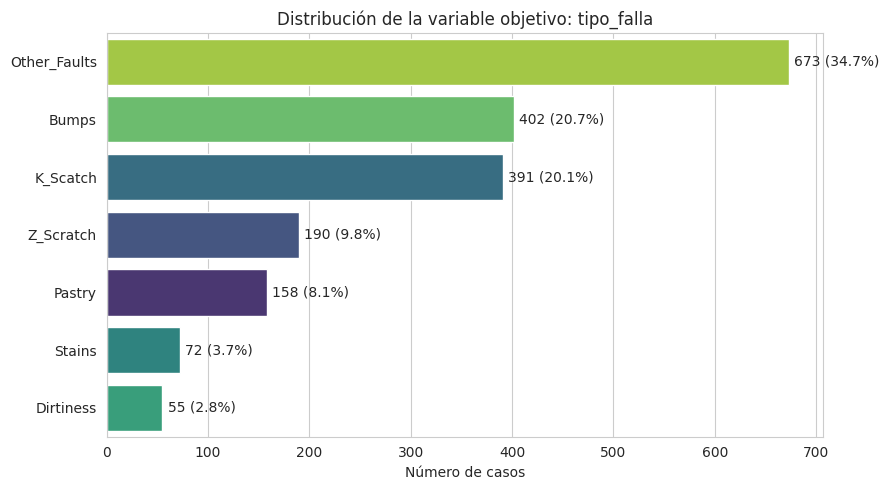

In [6]:
plt.figure(figsize=(9,5))
order = df['tipo_falla'].value_counts().index
ax = sns.countplot(data=df, y='tipo_falla', order=order, hue='tipo_falla', palette='viridis', legend=False)
for i, v in enumerate(df['tipo_falla'].value_counts()[order]):
    pct = 100*v/len(df)
    ax.text(v+5, i, f'{v} ({pct:.1f}%)', va='center')
plt.title('Distribución de la variable objetivo: tipo_falla')
plt.xlabel('Número de casos')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Hallazgo:** existe un desbalance de clases marcado. `Other_Faults` concentra el 34.7%
de los casos, mientras que `Dirtiness` apenas el 2.8%. Esto se aborda en la sección de
métricas previstas (F1-macro / balanced accuracy) y se retomará en T3 evaluando SMOTE
como estrategia complementaria de remuestreo.

## 3. Matriz de correlación entre variables predictoras

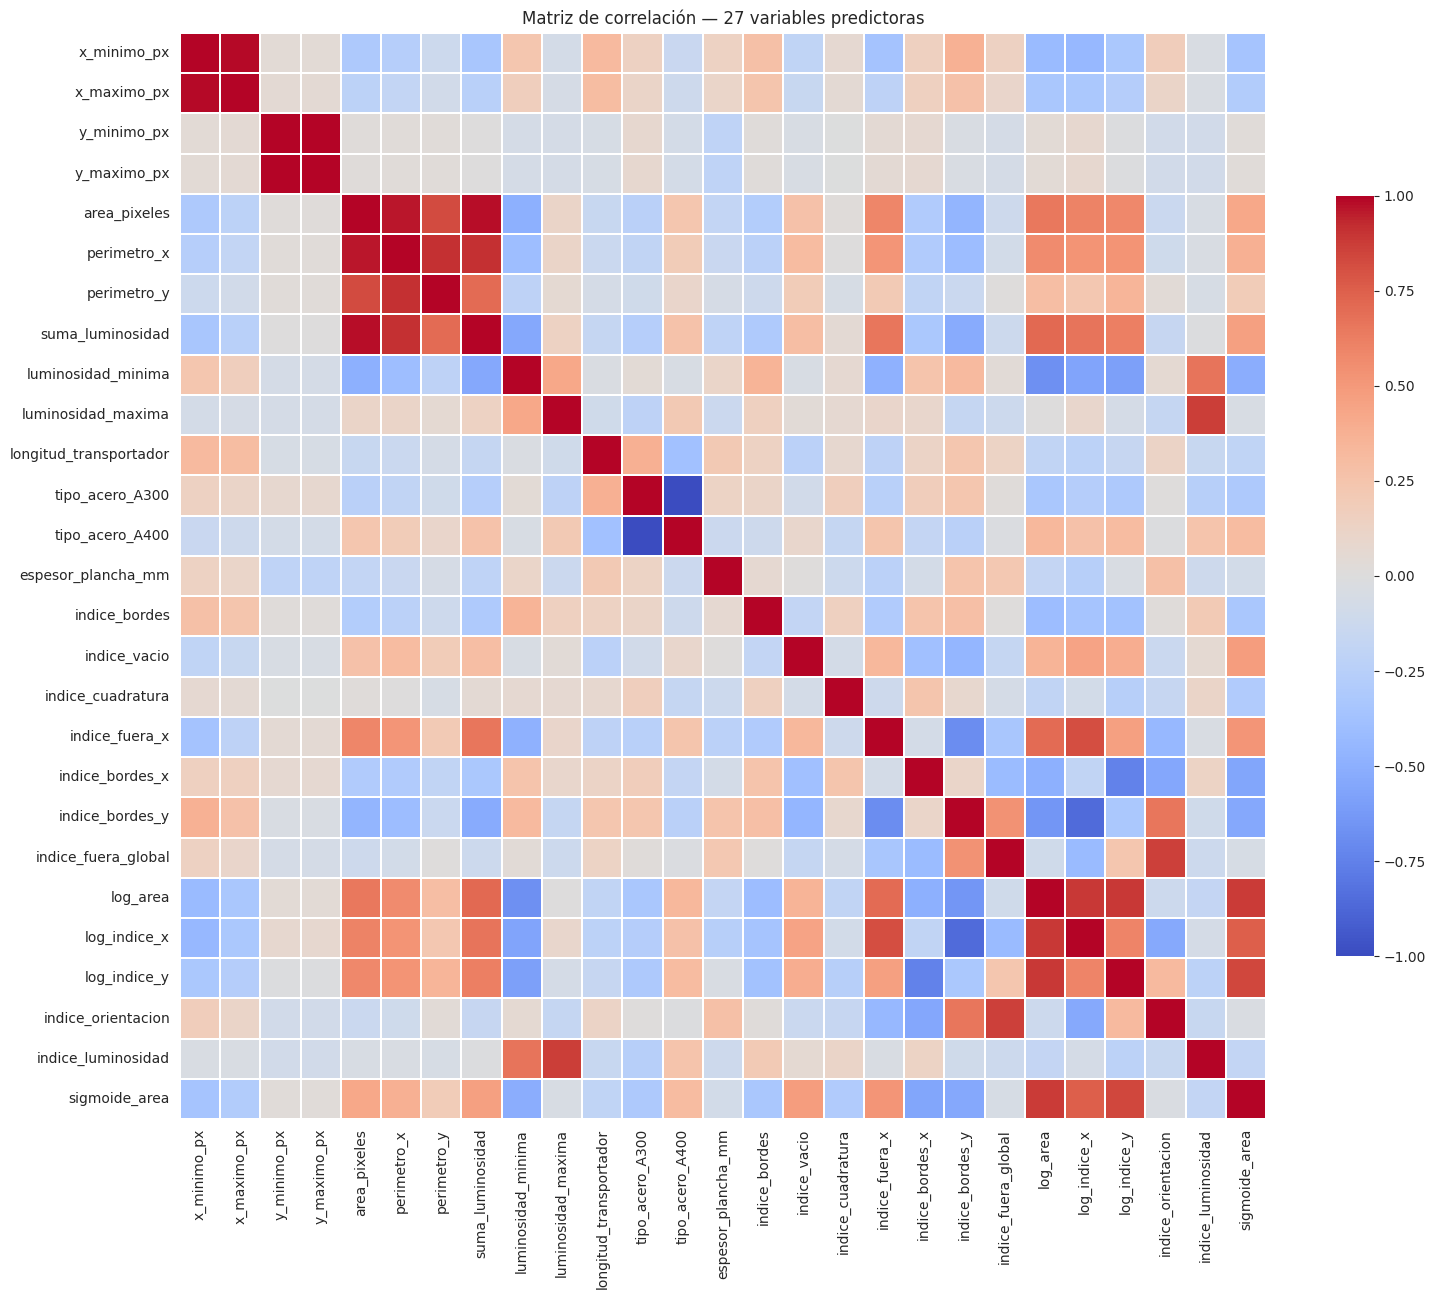

In [7]:
predictor_cols = ['x_minimo_px','x_maximo_px','y_minimo_px','y_maximo_px','area_pixeles',
'perimetro_x','perimetro_y','suma_luminosidad','luminosidad_minima','luminosidad_maxima',
'longitud_transportador','tipo_acero_A300','tipo_acero_A400','espesor_plancha_mm',
'indice_bordes','indice_vacio','indice_cuadratura','indice_fuera_x','indice_bordes_x',
'indice_bordes_y','indice_fuera_global','log_area','log_indice_x','log_indice_y',
'indice_orientacion','indice_luminosidad','sigmoide_area']

corr = df[predictor_cols].corr()

plt.figure(figsize=(16,13))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=0.3, cbar_kws={'shrink':0.7})
plt.title('Matriz de correlación — 27 variables predictoras')
plt.tight_layout()
plt.show()

In [8]:
# Pares de variables mas correlacionadas
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
corr_pairs.head(10)

tipo_acero_A400   tipo_acero_A300     1.000000
y_minimo_px       y_maximo_px         1.000000
x_maximo_px       x_minimo_px         0.988314
area_pixeles      suma_luminosidad    0.978952
                  perimetro_x         0.966644
suma_luminosidad  perimetro_x         0.912956
perimetro_y       perimetro_x         0.912436
log_area          log_indice_x        0.888919
                  log_indice_y        0.882974
sigmoide_area     log_area            0.877768
dtype: float64

**Hallazgo:** hay multicolinealidad fuerte entre varios pares de variables
(`tipo_acero_A300`/`A400` son binarias complementarias por definición; `y_minimo_px`/
`y_maximo_px` con r≈1.0; `area_pixeles`, `suma_luminosidad` y `perimetro_x` muy
correlacionadas entre sí). **Implicancia para el plan de algoritmos:** se prioriza
Random Forest / Gradient Boosting sobre modelos lineales, ya que los modelos basados en
árboles no se ven afectados por la multicolinealidad, mientras que una regresión
logística sí requeriría eliminar o combinar variables redundantes.

## 4. Comparación de variables clave por tipo de falla

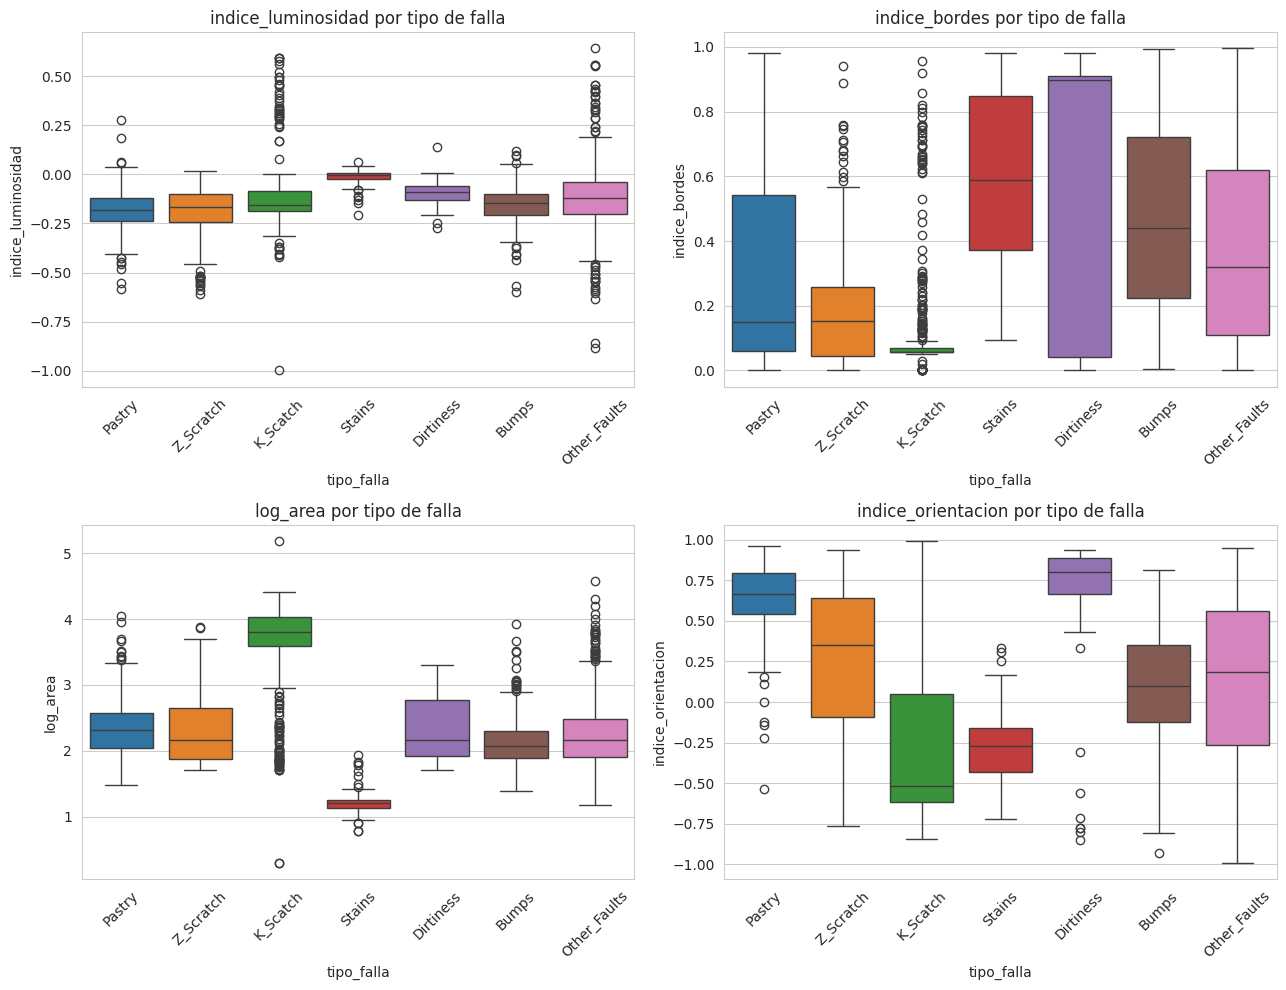

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13,10))

sns.boxplot(data=df, x='tipo_falla', y='indice_luminosidad', hue='tipo_falla', legend=False, ax=axes[0,0])
axes[0,0].set_title('indice_luminosidad por tipo de falla')
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='tipo_falla', y='indice_bordes', hue='tipo_falla', legend=False, ax=axes[0,1])
axes[0,1].set_title('indice_bordes por tipo de falla')
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='tipo_falla', y='log_area', hue='tipo_falla', legend=False, ax=axes[1,0])
axes[1,0].set_title('log_area por tipo de falla')
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='tipo_falla', y='indice_orientacion', hue='tipo_falla', legend=False, ax=axes[1,1])
axes[1,1].set_title('indice_orientacion por tipo de falla')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Foco específico: Stains vs. Dirtiness (el par más propenso a confundirse)

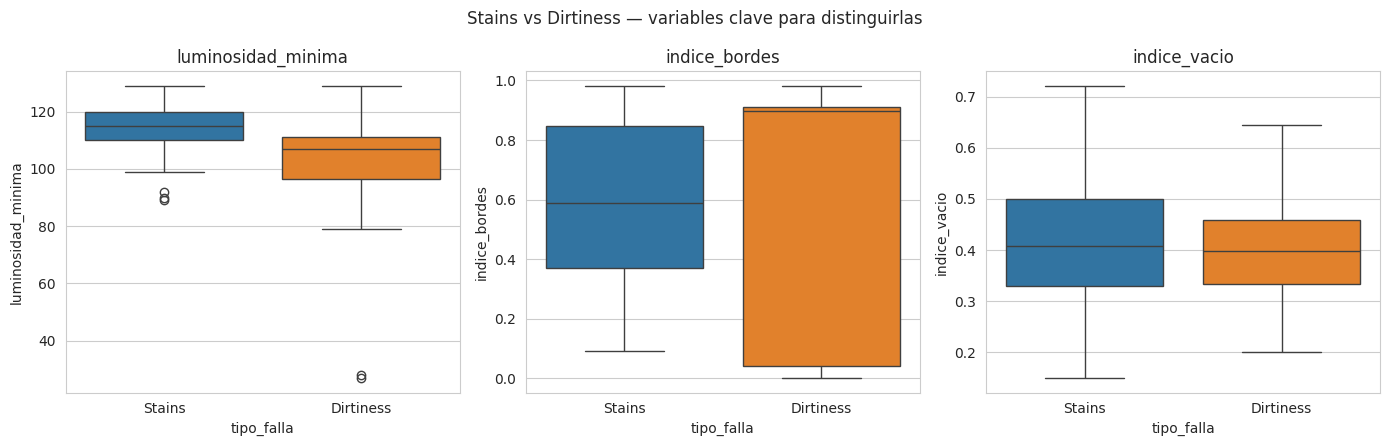

In [10]:
sub = df[df['tipo_falla'].isin(['Stains','Dirtiness'])]
fig, axes = plt.subplots(1, 3, figsize=(14,4.5))
for ax, col in zip(axes, ['luminosidad_minima','indice_bordes','indice_vacio']):
    sns.boxplot(data=sub, x='tipo_falla', y=col, hue='tipo_falla', legend=False, ax=ax)
    ax.set_title(col)
plt.suptitle('Stains vs Dirtiness — variables clave para distinguirlas')
plt.tight_layout()
plt.show()

**Hallazgo:** `Stains` y `Dirtiness` muestran distribuciones parcialmente solapadas en
`luminosidad_minima` e `indice_bordes`, lo que anticipa que podrían ser las clases más
difíciles de separar para el modelo — se confirmará con la matriz de confusión en T3, y
se planea usar Partial Dependence Plots específicamente sobre este par en la etapa de
interpretabilidad.

## 5. Plan de Algoritmos

| Algoritmo | Rol | Justificación |
|---|---|---|
| **Random Forest** | Modelo principal | Robusto a la multicolinealidad detectada; maneja bien variables numéricas y binarias mezcladas; entrega `feature_importances_` interpretable |
| **Gradient Boosting (XGBoost)** | Modelo de comparación | Suele superar a Random Forest en datasets tabulares medianos; permite contrastar si la mejora justifica su menor interpretabilidad |
| **SVM (kernel RBF)** | Baseline de referencia | Punto de comparación clásico, más sensible a escalado y menos interpretable |

Se descarta Clustering por tratarse de un problema de clasificación supervisada con
etiquetas conocidas (no de agrupamiento no supervisado). Se descartan redes neuronales
profundas porque, con solo 1,941 filas, el riesgo de sobreajuste es alto y no ofrecen
ventaja clara sobre modelos de árboles en datos tabulares de este tamaño (justificación
de Computabilidad bajo el marco VDS).

## 6. Métricas Previstas

- **F1-macro** (métrica principal): trata todas las clases por igual, evitando que
  `Other_Faults` (34.7%) domine la evaluación.
- **Balanced accuracy** (métrica secundaria): confirma el resultado del F1-macro desde
  otro ángulo.
- **Matriz de confusión**: para verificar específicamente la confusión entre `Stains` y
  `Dirtiness` anticipada en la sección 4.
- **Accuracy global**: se reporta solo como referencia, dejando explícito que no es la
  métrica de decisión dado el desbalance de clases.
